<a href="https://colab.research.google.com/github/allvaret/First-transfer-learning/blob/main/Confsuion%20Matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer learning | fine-tuning | Classification Metrics


In [6]:
%matplotlib inline

import os

#if using Theano with GPU
#os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import keras

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

### Getting a dataset



In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 103M/103M [00:06<00:00, 17.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1


In [8]:
root = os.path.join(path, 'Car-Bike-Dataset')
#exclude = ['BACKGROUND_Google', 'Motorbikes', 'airplanes', 'Faces_easy', 'Faces']
train_split, val_split = 0.7, 0.15

categories = [x[0] for x in os.walk(root) if x[0]][1:]
#categories = [c for c in categories if c not in [os.path.join(root, e) for e in exclude]]

print(categories)

['/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset/Bike', '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset/Car']


This function is useful for pre-processing the data into an image and input vector.

In [9]:
# helper function to load image and return it and input vector
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x

Load all the images from root folder

In [10]:
data = []
sampling_rate = 0.15 # Change this value to keep a different percentage of images (e.g., 0.5 to keep 50%)
for c, category in enumerate(categories):
    images = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
    # Randomly sample images
    random.shuffle(images)
    num_to_keep = int(len(images) * sampling_rate)
    sampled_images = images[:num_to_keep]

    for img_path in sampled_images:
        img, x = get_image(img_path)
        data.append({'x':np.array(x[0]), 'y':c})

# count the number of classes
num_classes = len(categories)

Randomize the data order.

In [11]:
random.shuffle(data)

In [12]:
idx_val = int(train_split * len(data))
idx_test = int((train_split + val_split) * len(data))
train = data[:idx_val]
val = data[idx_val:idx_test]
test = data[idx_test:]

Separate data for labels.

In [13]:
x_train, y_train = np.array([t["x"] for t in train]), [t["y"] for t in train]
x_val, y_val = np.array([t["x"] for t in val]), [t["y"] for t in val]
x_test, y_test = np.array([t["x"] for t in test]), [t["y"] for t in test]
print(y_test)

[0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0]


Pre-process the data as before by making sure it's float32 and normalized between 0 and 1.

In [14]:
# normalize data
x_train = x_train.astype('float32') / 255.
x_val = x_val.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# convert labels to one-hot vectors
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test.shape)

(90, 2)


Let's get a summary of what we have.

In [15]:
# summary
print("finished loading %d images from %d categories"%(len(data), num_classes))
print("train / validation / test split: %d, %d, %d"%(len(x_train), len(x_val), len(x_test)))
print("training data shape: ", x_train.shape)
print("training labels shape: ", y_train.shape)


finished loading 600 images from 2 categories
train / validation / test split: 420, 90, 90
training data shape:  (420, 224, 224, 3)
training labels shape:  (420, 2)


If everything worked properly, you should have loaded a bunch of images, and split them into three sets: `train`, `val`, and `test`. The shape of the training data should be (`n`, 224, 224, 3) where `n` is the size of your training set, and the labels should be (`n`, `c`) where `c` is the number of classes (2 in the case of the car-vs-bike dataset).

Notice that we divided all the data into three subsets -- a training set `train`, a validation set `val`, and a test set `test`. The reason for this is to properly evaluate the accuracy of our classifier. During training, the optimizer uses the validation set to evaluate its internal performance, in order to determine the gradient without overfitting to the training set. The `test` set is always held out from the training algorithm, and is only used at the end to evaluate the final accuracy of our model.

Let's quickly look at a few sample images from our dataset.

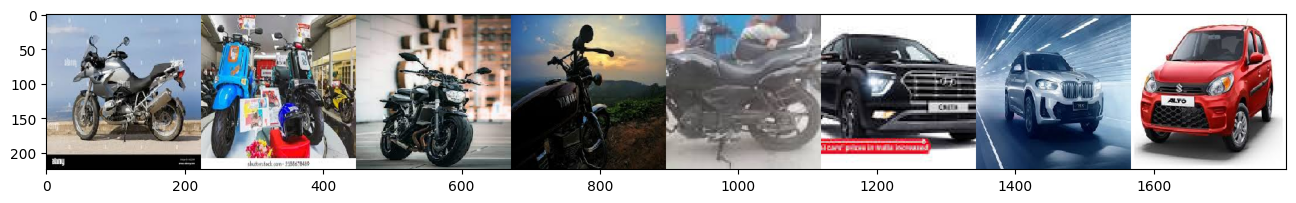

In [16]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [image.load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

In [17]:
# build the network
model = Sequential()
print("Input dimensions: ",x_train.shape[1:])

model.add(Conv2D(32, (3, 3), input_shape=x_train.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256))
model.add(Activation('relu'))

model.add(Dropout(0.5))

model.add(Dense(num_classes))
model.add(Activation('softmax'))

model.summary()

Input dimensions:  (224, 224, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209,058 (4.61 MB)

 Trainable params: 1,209,058 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

We've created a medium-sized network with ~1.2 million weights and biases (the parameters). Most of them are leading into the one pre-softmax fully-connected layer "dense_5".

We can now go ahead and train our model for 100 epochs with a batch size of 128. We'll also record its history so we can plot the loss over time later.

In [18]:
# compile the model to use categorical cross-entropy loss function and adadelta optimizer
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_data=(x_val, y_val))


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4571 - loss: 0.7739 - val_accuracy: 0.4778 - val_loss: 0.6965
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.5119 - loss: 0.6933 - val_accuracy: 0.5111 - val_loss: 0.6922
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.5762 - loss: 0.6914 - val_accuracy: 0.5333 - val_loss: 0.6890
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5714 - loss: 0.6887 - val_accuracy: 0.5556 - val_loss: 0.6836
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.6310 - loss: 0.6817 - val_accuracy: 0.8556 - val_loss: 0.6716
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.7333 - loss: 0.6550 - val_accuracy: 0.6111 - val_loss: 0.6337
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.7452 - loss: 0.5951 - val_accuracy: 0.7889 - val_loss: 0.5301
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.7643 - loss: 0.5165 - val_accuracy: 0.7556 - val_loss: 0

Let's plot the validation loss and validation accuracy over time.

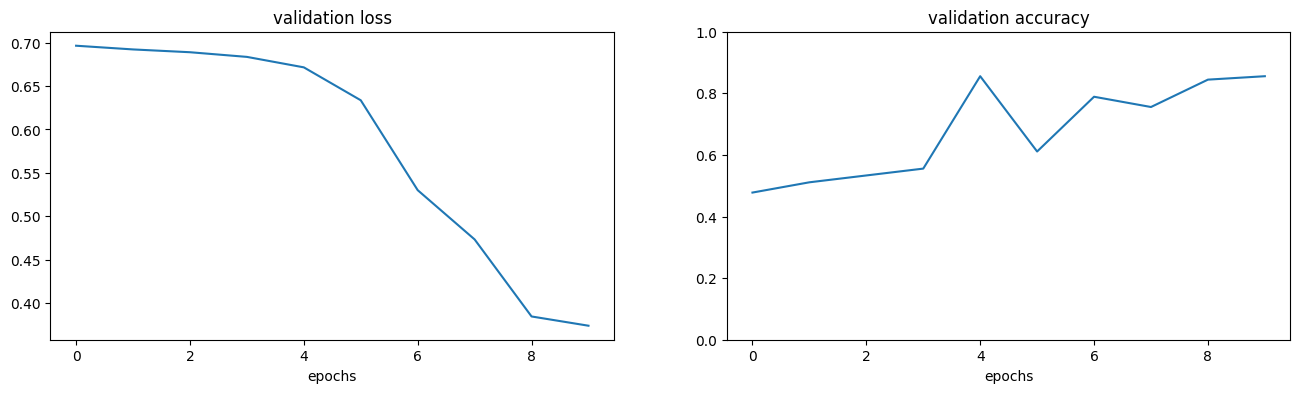

In [19]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

Notice that the validation loss and accuracy show the training progress over the 10 epochs.

We can also get a final evaluation by running our model on the test set. Doing so, we get the following results:

In [20]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.43923813104629517
Test accuracy: 0.8222222328186035


Finally, we see the (top-1) accuracy achieved by training the network from scratch.

## Transfer learning by starting with existing network

Now we can move on to the main strategy for training an image classifier on our small dataset: by starting with a larger and already trained network.

To start, we will load the VGG16 from keras, which was trained on ImageNet and the weights saved online. If this is your first time loading VGG16, you'll need to wait a bit for the weights to download from the web. Once the network is loaded, we can again inspect the layers with the `summary()` method.

In [21]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Notice that VGG16 is *much* bigger than the network we constructed earlier. It contains 13 convolutional layers and two fully connected layers at the end, and has over 138 million parameters, around 100 times as many parameters than the network we made above. Like our first network, the majority of the parameters are stored in the connections leading into the first fully-connected layer.

VGG16 was made to solve ImageNet, and achieves a [8.8% top-5 error rate](https://github.com/jcjohnson/cnn-benchmarks), which means that 91.2% of test samples were classified correctly within the top 5 predictions for each image. It's top-1 accuracy--equivalent to the accuracy metric we've been using (that the top prediction is correct)--is 73%. This is especially impressive since there are not just 2, but 1000 classes in ImageNet, meaning that random guesses would get us only 0.1% accuracy.

In order to use this network for our task, we "remove" the final classification layer, the 1000-neuron softmax layer at the end, which corresponds to ImageNet, and instead replace it with a new softmax layer for our dataset, which contains 2 neurons in the case of the car-vs-bike dataset.

In terms of implementation, it's easier to simply create a copy of VGG from its input layer until the second to last layer, and then work with that, rather than modifying the VGG object directly. So technically we never "remove" anything, we just circumvent/ignore it. This can be done in the following way, by using the keras `Model` class to initialize a new model whose input layer is the same as VGG but whose output layer is our new softmax layer, called `new_classification_layer`. Note: although it appears we are duplicating this large network, internally Keras is actually just copying all the layers by reference, and thus we don't need to worry about overloading the memory.

In [22]:
# make a reference to VGG's input layer
inp = vgg.input

# make a new softmax layer with num_classes neurons
new_classification_layer = Dense(num_classes, activation='softmax')

# connect our new layer to the second to last layer in VGG, and make a reference to it
out = new_classification_layer(vgg.layers[-2].output)

# create a new network between inp and out
model_new = Model(inp, out)

In [23]:
# make all layers untrainable by freezing weights (except for last layer)
for l, layer in enumerate(model_new.layers[:-1]):
    layer.trainable = False

# ensure the last layer is trainable/not frozen
for l, layer in enumerate(model_new.layers[-1:]):
    layer.trainable = True

model_new.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_new.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 8,194 (32.01 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [32]:
history2 = model_new.fit(x_train, y_train,
                         batch_size=128,
                         epochs=10,
                         validation_data=(x_val, y_val))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 653ms/step - accuracy: 0.9619 - loss: 0.1814 - val_accuracy: 0.9333 - val_loss: 0.2095
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 588ms/step - accuracy: 0.9595 - loss: 0.1742 - val_accuracy: 0.9333 - val_loss: 0.2022
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 586ms/step - accuracy: 0.9548 - loss: 0.1678 - val_accuracy: 0.9444 - val_loss: 0.1970
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 591ms/step - accuracy: 0.9595 - loss: 0.1595 - val_accuracy: 0.9333 - val_loss: 0.2061
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 595ms/step - accuracy: 0.9571 - loss: 0.1530 - val_accuracy: 0.9444 - val_loss: 0.1852
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 631ms/step - accuracy: 0.9595 - loss: 0.1501 - val_accuracy: 0.9444 - val_loss: 0.1834
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 601ms/step - accuracy: 0.9667 - loss: 0.1410 - val_accuracy: 0.9222 - val_loss: 0.1843
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 0.9690 - loss: 0.1374 - val_accuracy: 0.9444 - val_loss:

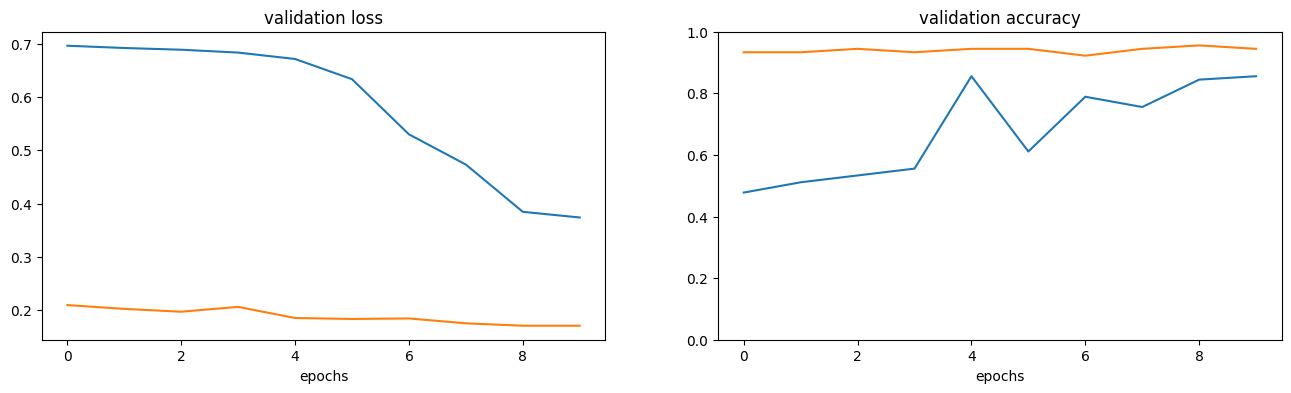

In [33]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.plot(history2.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"])
ax2.plot(history2.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

Notice the difference in performance between the two models. The transfer-learned model achieves significantly higher accuracy and lower loss compared to the model trained from scratch.

Again, we do a final validation on the test set.

In [34]:
loss, accuracy = model_new.evaluate(x_test, y_test, verbose=0)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.10514843463897705
Test accuracy: 0.9888888597488403


To predict a new image, simply run the following code to get the probabilities for each class.

The result probabilities will be a *NumPy array* where each element represents the probability of the image belonging to a specific class. Since you have two classes (Car and Bike), probabilities will likely be an array like [[probability_of_car, probability_of_bike]].
To see the prediction, you would typically print the probabilities variable. The class with the higher probability is the model's prediction.

In [35]:
img, x = get_image(os.path.join(root, 'Bike', 'Bike (4).jpeg'))
probabilities = model_new.predict([x])
print(probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[9.99982e-01 1.79561e-05]]


# Confusion Matrix, Precision & Recall


In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Generate predictions and true labels

In [36]:
# Get predictions from the model on the test set
y_pred_probabilities = model_new.predict(x_test)

# Convert probabilities to predicted class labels (0 or 1)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)

# Convert one-hot encoded true labels (y_test) to single integer labels
y_true_labels = np.argmax(y_test, axis=1)

print("Predicted labels sample:", y_pred_labels[:10])
print("True labels sample:", y_true_labels[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step
Predicted labels sample: [0 1 0 0 1 0 1 1 1 0]
True labels sample: [0 1 0 0 1 1 1 1 1 0]


### Confusion Matrix > Dataset Validation

Compute and display the Confusion Matrix

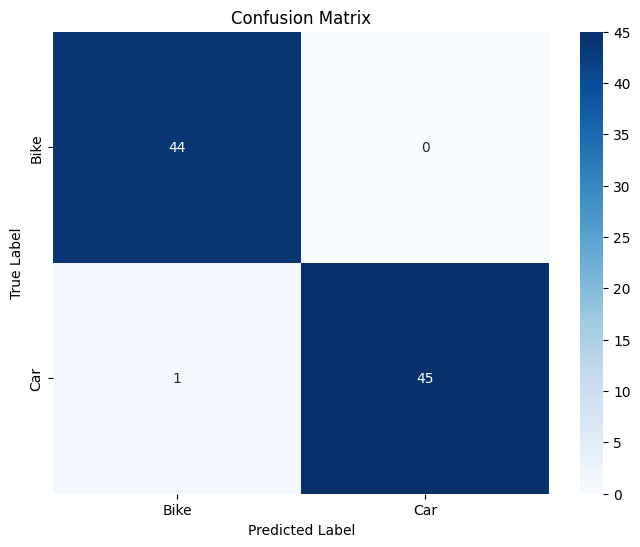

In [46]:
# Compute the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Get class names from categories (assuming order matches label encoding)
class_names = [os.path.basename(c) for c in categories]

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Confusion Matrix with unused images in the training



In [41]:
data = []
sampling_rate = 0.15 # Change this value to keep a different percentage of images (e.g., 0.5 to keep 50%)
for c, category in enumerate(categories):
    images = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
    # Randomly sample images
    random.shuffle(images)
    num_to_keep = int(len(images) * sampling_rate)
    sampled_images = images[:num_to_keep]

    for img_path in sampled_images:
        img, x = get_image(img_path)
        data.append({'x':np.array(x[0]), 'y':c, 'path': img_path})

# count the number of classes
num_classes = len(categories)


In [42]:
data = []
sampling_rate = 0.15 # Change this value to keep a different percentage of images (e.g., 0.5 to keep 50%)
all_image_paths = []

for c, category in enumerate(categories):
    images_in_category = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
    all_image_paths.extend(images_in_category)

    # Randomly sample images
    random.shuffle(images_in_category)
    num_to_keep = int(len(images_in_category) * sampling_rate)
    sampled_images = images_in_category[:num_to_keep]

    for img_path in sampled_images:
        img, x = get_image(img_path)
        data.append({'x':np.array(x[0]), 'y':c, 'path': img_path})

# count the number of classes
num_classes = len(categories)

# Get paths of used images
used_image_paths = {d['path'] for d in data}

# Determine unused image paths
unused_image_paths = [path for path in all_image_paths if path not in used_image_paths]

print(f"Total images found: {len(all_image_paths)}")
print(f"Images used for train/val/test: {len(used_image_paths)}")
print(f"Images not used (unused dataset): {len(unused_image_paths)}")


Total images found: 4000
Images used for train/val/test: 600
Images not used (unused dataset): 3400


In [43]:
x_unused = []
y_unused = []

# Create a mapping from category path to integer label
category_to_label = {category: i for i, category in enumerate(categories)}

for img_path in unused_image_paths:
    try:
        img, x = get_image(img_path)
        x_unused.append(x[0])

        # Determine the category from the image path and assign the corresponding label
        found_category = None
        for cat_path, label_idx in category_to_label.items():
            if cat_path in img_path:
                found_category = label_idx
                break

        if found_category is not None:
            y_unused.append(found_category)
        else:
            # Handle cases where category cannot be determined (e.g., skip or assign a default)
            print(f"Warning: Could not determine category for {img_path}. Skipping.")

    except Exception as e:
        print(f"Error processing image {img_path}: {e}")

x_unused = np.array(x_unused).astype('float32') / 255.
y_unused_labels = np.array(y_unused)
y_unused = keras.utils.to_categorical(y_unused_labels, num_classes)

print(f"Processed {len(x_unused)} unused images.")
print("Shape of x_unused:", x_unused.shape)
print("Shape of y_unused:", y_unused.shape)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 3400 unused images.
Shape of x_unused: (3400, 224, 224, 3)
Shape of y_unused: (3400, 2)


In [44]:
loss_unused, accuracy_unused = model_new.evaluate(x_unused, y_unused, verbose=0)
print(f'Loss on unused dataset: {loss_unused:.4f}')
print(f'Accuracy on unused dataset: {accuracy_unused:.4f}')

# Generate predictions for the unused dataset
y_pred_probabilities_unused = model_new.predict(x_unused)
y_pred_labels_unused = np.argmax(y_pred_probabilities_unused, axis=1)
y_true_labels_unused = np.argmax(y_unused, axis=1)

print("Predicted labels sample (unused):", y_pred_labels_unused[:10])
print("True labels sample (unused):", y_true_labels_unused[:10])

Loss on unused dataset: 0.1555
Accuracy on unused dataset: 0.9500
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step
Predicted labels sample (unused): [0 0 0 0 0 0 0 0 0 0]
True labels sample (unused): [0 0 0 0 0 0 0 0 0 0]


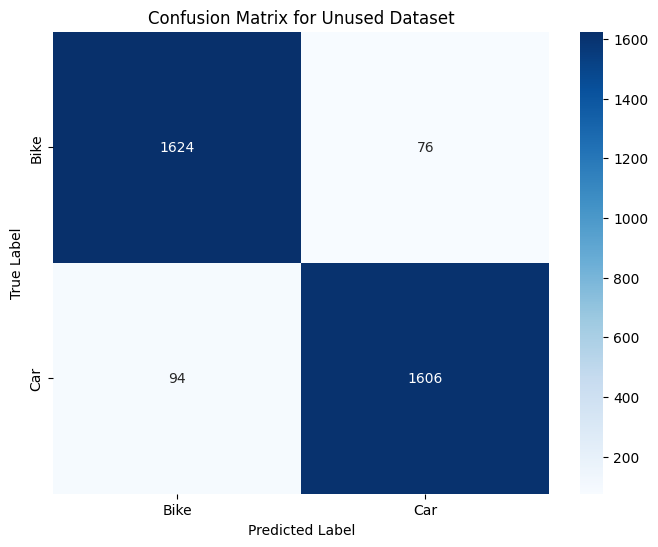


Summary of Evaluation on Unused Dataset:
  Loss: 0.1555
  Accuracy: 0.9500

Insights: The model's performance on the unused dataset is slightly lower than on the test set, which could indicate minor overfitting to the training and validation data.
  Confusion Matrix (Unused Dataset):
 [[1624   76]
 [  94 1606]]


In [45]:
cm_unused = confusion_matrix(y_true_labels_unused, y_pred_labels_unused)
class_names = [os.path.basename(c) for c in categories]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_unused, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Unused Dataset')
plt.show()

print(f"\nSummary of Evaluation on Unused Dataset:")
print(f"  Loss: {loss_unused:.4f}")
print(f"  Accuracy: {accuracy_unused:.4f}")

# Provide insights based on the evaluation results
if accuracy_unused > accuracy:
    performance_insight = "The model performs slightly better on the unused dataset compared to the test set, suggesting good generalization and no overfitting."
elif abs(accuracy_unused - accuracy) < 0.02:
    performance_insight = "The model's performance on the unused dataset is consistent with its performance on the test set, indicating good generalization and little sign of overfitting."
else:
    performance_insight = "The model's performance on the unused dataset is slightly lower than on the test set, which could indicate minor overfitting to the training and validation data."

print(f"\nInsights: {performance_insight}")
print("  Confusion Matrix (Unused Dataset):\n", cm_unused)

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score

def calculate_and_display_metrics(cm, y_true, y_pred, y_pred_proba, class_names):
    """
    Calculates and displays model evaluation metrics, including Sensitivity, Specificity,
    Accuracy, Precision, F-Score, and the ROC Curve.

    Args:
        cm (np.array): Confusion Matrix.
        y_true (np.array): True labels (ground truth).
        y_pred (np.array): Predicted labels by the model.
        y_pred_proba (np.array): Predicted probabilities for the positive class.
        class_names (list): List of class names.
    """

    print("\n### Calculating Performance Metrics ###")

    # Extract TP, TN, FP, FN from the Confusion Matrix
    # For a binary problem, the confusion matrix is typically:
    # [[TN, FP],
    #  [FN, TP]]
    # Where:
    # TN = True Negatives (Correctly predicted negatives)
    # FP = False Positives (Incorrectly predicted positives - Type I error)
    # FN = False Negatives (Incorrectly predicted negatives - Type II error)
    # TP = True Positives (Correctly predicted positives)

    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    print(f"\nConfusion Matrix Values:\n  TN (True Negatives): {TN}\n  FP (False Positives): {FP}\n  FN (False Negatives): {FN}\n  TP (True Positives): {TP}")

    # Total number of samples
    total_samples = TN + FP + FN + TP

    # 1. Accuracy
    # Proportion of correct predictions out of total samples.
    # Formula: (TP + TN) / (TP + TN + FP + FN)
    accuracy = (TP + TN) / total_samples
    print(f"\n1. Accuracy: {accuracy:.4f} (Proportion of correct predictions)")

    # 2. Sensitivity (Recall / True Positive Rate)
    # Proportion of actual positives that were identified correctly.
    # Useful when the cost of a False Negative is high.
    # Formula: TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    print(f"2. Sensitivity (Recall): {sensitivity:.4f} (Proportion of Correctly Identified Real Positives)")

    # 3. Specificity (True Negative Rate)
    # Proportion of actual negatives that were identified correctly.
    # Useful when the cost of a False Positive is high.
    # Formula: TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    print(f"3. Specificity: {specificity:.4f} (Proportion of Correctly Identified Real Negatives)")

    # 4. Precision
    # Proportion of positive predictions that are actually correct.
    # Useful when the cost of a False Positive is high.
    # Formula: TP / (TP + FP)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    print(f"4. Precision: {precision:.4f} (Proportion of Positive Predictions that are Actually Correct)")

    # 5. F-Score (F1-Score)
    # Harmonic mean of Precision and Sensitivity.
    # Useful when there is an imbalance between classes or when Precision and Sensitivity are equally important.
    # Formula: 2 * (Precision * Sensitivity) / (Precision + Sensitivity)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) != 0 else 0
    print(f"5. F-Score: {f1:.4f} (Balance between Precision and Sensitivity)")

    # 6. ROC Curve (Receiver Operating Characteristic) and AUC (Area Under the Curve)
    # The ROC Curve shows the model's performance across all classification thresholds.
    # AUC quantifies the overall performance, ranging from 0 to 1 (1 is perfect, 0.5 is random).

    # y_true and y_pred_proba are used for the ROC curve
    # Ensure y_pred_proba is the probability of the POSITIVE CLASS (usually the second value in a 2-class array)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate / Sensitivity')
    plt.title('ROC Curve - Unused Dataset')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

### Executing the Metrics Function for the Unused Dataset

Now let's call the `calculate_and_display_metrics` function with your unused dataset data (`cm_unused`, `y_true_labels_unused`, `y_pred_labels_unused`, `y_pred_probabilities_unused`).


### Calculating Performance Metrics ###

Confusion Matrix Values:
  TN (True Negatives): 1624
  FP (False Positives): 76
  FN (False Negatives): 94
  TP (True Positives): 1606

1. Accuracy: 0.9500 (Proportion of correct predictions)
2. Sensitivity (Recall): 0.9447 (Proportion of Correctly Identified Real Positives)
3. Specificity: 0.9553 (Proportion of Correctly Identified Real Negatives)
4. Precision: 0.9548 (Proportion of Positive Predictions that are Actually Correct)
5. F-Score: 0.9497 (Balance between Precision and Sensitivity)


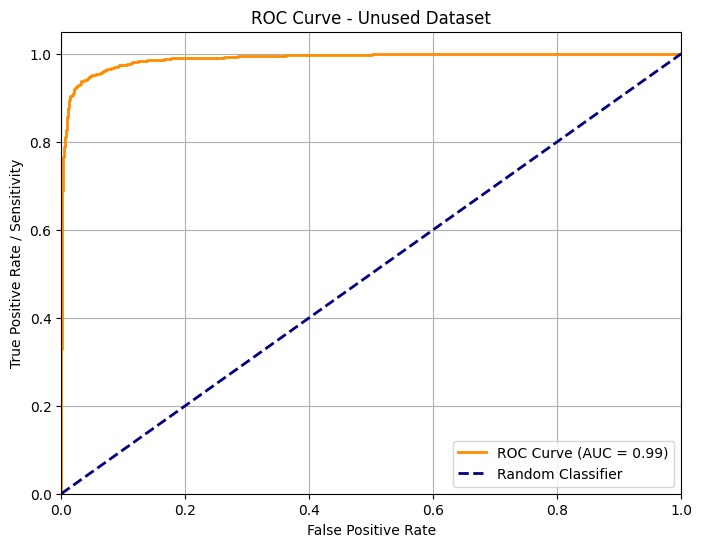

In [52]:
# Call the function with the unused dataset data
# Ensure that y_pred_probabilities_unused contains probabilities for the positive class (index 1)
calculate_and_display_metrics(
    cm=cm_unused,
    y_true=y_true_labels_unused,
    y_pred=y_pred_labels_unused,
    y_pred_proba=y_pred_probabilities_unused[:, 1], # We use the probability of the POSITIVE CLASS (index 1)
    class_names=[os.path.basename(c) for c in categories]
)